In [1]:
import pandas as pd

# Load raw dataset using relative path
df = pd.read_csv('../data/raw/customer_data.csv')

# View first 5 rows
df.head()

,CustomerID,City,Monthly_Spend,Years,Age,Churn,Join_Date
0,1001,Bandung,568.351195,8.0,26,0,2024-07-13
1,1002,Medan,875.234168,1.0,56,1,2024-08-15
2,1003,Jakarta,690.084768,1.0,45,0,2025-03-06
3,1004,Bandung,384.619269,12.0,20,0,2025-03-11
4,1005,Bandung,320.317066,7.0,37,0,2025-04-05


In [2]:
# Check missing values and data types
df.info()
print("\n Missing values per column: \n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     1000 non-null   int64  
 1   City           1000 non-null   str    
 2   Monthly_Spend  1000 non-null   float64
 3   Years          951 non-null    float64
 4   Age            1000 non-null   int64  
 5   Churn          1000 non-null   int64  
 6   Join_Date      1000 non-null   str    
dtypes: float64(2), int64(3), str(2)
memory usage: 54.8 KB

 Missing values per column: 
 CustomerID        0
City              0
Monthly_Spend     0
Years            49
Age               0
Churn             0
Join_Date         0
dtype: int64


In [3]:
# 1. Fill missing 'Years' values with the median tenure

years_median = df['Years'].median()
df['Years'] = df['Years'].fillna(years_median)


# 2. Convert 'Join_Date' to determine time object
df['Join_Date'] = pd.to_datetime(df['Join_Date'])

# 3. Verify that no missing value remain
print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 CustomerID       0
City             0
Monthly_Spend    0
Years            0
Age              0
Churn            0
Join_Date        0
dtype: int64


In [4]:
df.describe()

,CustomerID,Monthly_Spend,Years,Age,Churn,Join_Date
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
mean,1500.500000,508.439792,7.583000,43.960000,0.202000,2024-12-31 11:38:24
min,1001.000000,20.000000,1.000000,18.000000,0.000000,2024-01-01 00:00:00
25%,1250.750000,374.999078,4.000000,31.000000,0.000000,2024-07-05 00:00:00
50%,1500.500000,507.326703,8.000000,44.000000,0.000000,2024-12-31 00:00:00
75%,1750.250000,636.319679,11.000000,57.000000,0.000000,2025-06-25 00:00:00
max,2000.000000,1115.776162,14.000000,69.000000,1.000000,2025-12-30 00:00:00
std,288.819436,199.196193,3.906965,14.890874,0.401693,NaN


In [5]:
# 1. Create a new numerical feature from the Join_Date
# Tenure in days from a fixed benchmark date (or total membership days)

benchmark_date = pd.to_datetime('2026-01-01')
df['Tenure_Days'] = (benchmark_date - df['Join_Date']).dt.days

# Drop original date and ID column  that won't help the model predict churn
df_model = df.drop(columns=['CustomerID', 'Join_Date'])

# 2. One-Hot Encoding for categorical variables (text to 0/1 columns )
df_encoded = pd.get_dummies(df_model, drop_first=True)

# Inspect the prepared dataset
df_encoded.head()


,Monthly_Spend,Years,Age,Churn,Tenure_Days,City_Jakarta,City_Medan,City_Surabaya
0,568.351195,8.0,26,0,537,False,False,False
1,875.234168,1.0,56,1,504,False,True,False
2,690.084768,1.0,45,0,301,True,False,False
3,384.619269,12.0,20,0,296,False,False,False
4,320.317066,7.0,37,0,271,False,False,False


In [6]:
# Separate features and target

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (1000, 7)
Target shape (y): (1000,)


In [7]:
from sklearn.model_selection import train_test_split

# Split the data into 80% train and 20% test

X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 800, Testing samples: 200


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the Random Forest model
model_rf = RandomForestClassifier(random_state=42)

# 2. Train (fit) the model on the 80% training data
model_rf.fit(X_train, y_train)

# 3. Predict on the 20% unseen test data
y_pred = model_rf.predict(X_test)

# 4. Check perfomance
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:2f}%\n")
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 79.000000%

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.99      0.88       160
           1       0.00      0.00      0.00        40

    accuracy                           0.79       200
   macro avg       0.40      0.49      0.44       200
weighted avg       0.64      0.79      0.71       200



In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score

# Train Random Forest with balanced class weights
model_rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf_balanced.fit(X_train, y_train)

# Predict on test data
y_pred_balanced = model_rf_balanced.predict(X_test)

# Evaluate result
print("--- Balanced Random Forest Performance ---")
print(classification_report(y_test, y_pred_balanced))

--- Balanced Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       160
           1       0.17      0.07      0.10        40

    accuracy                           0.74       200
   macro avg       0.48      0.49      0.48       200
weighted avg       0.67      0.74      0.70       200



In [14]:
# Using XGBoost 

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Calculate ratio of non-churners to churners
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Initialize and train XGBoost 
model_xgb = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

# 3. Predict on test set
y_pred_xgb = model_xgb.predict(X_test)

print("--- XGBoost Performance ---")
print(classification_report(y_test, y_pred_xgb))



--- XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       160
           1       0.09      0.07      0.08        40

    accuracy                           0.67       200
   macro avg       0.44      0.45      0.44       200
weighted avg       0.64      0.67      0.66       200



In [13]:
# Probability Threshold Tuning

import numpy as np

# 1. Get raw probability predictions for Class 1 (Churn) from Random Forest
y_probs = model_rf_balanced.predict_proba(X_test)[:, 1]

# 2. Apply custom threshold of 30% (0.30) instead of default 50% (0.50)
custom_threshold = 0.30
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f"--- Random Forest with Custom Threshold ({custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom))


--- Random Forest with Custom Threshold (0.3) ---
              precision    recall  f1-score   support

           0       0.78      0.40      0.53       160
           1       0.19      0.55      0.28        40

    accuracy                           0.43       200
   macro avg       0.48      0.48      0.40       200
weighted avg       0.66      0.43      0.48       200



C:\Users\steve\AppData\Local\Temp\ipykernel_14408\4262303479.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


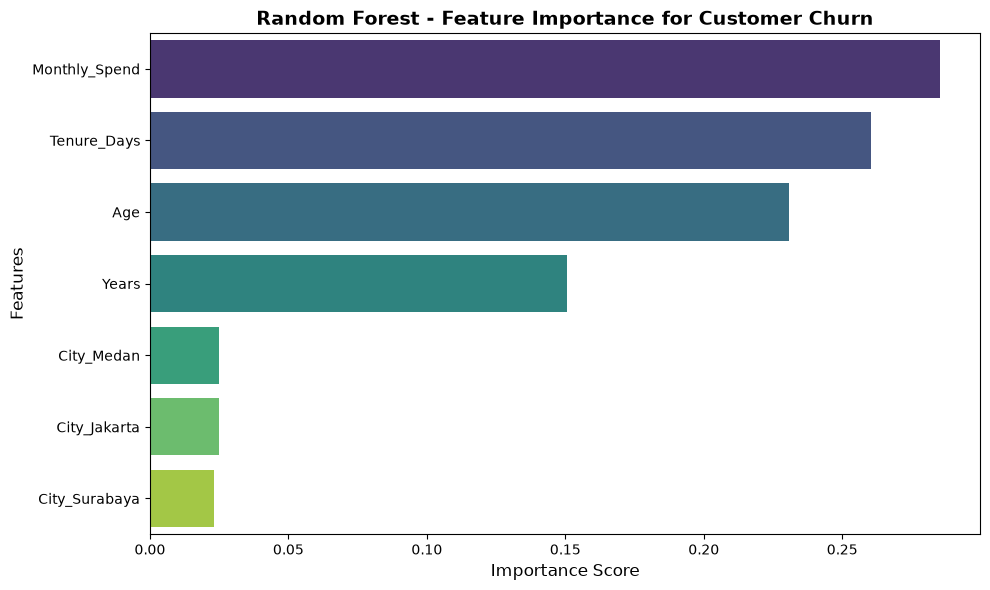

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract feature importance from the trained Random Forest model
importances = model_rf_balanced.feature_importances_
feature_names = X.columns

# 2. Create DataFrame for easy sorting and plotting
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df,
    palette='viridis'
)

plt.title('Random Forest - Feature Importance for Customer Churn', fontsize=14, fontweight='bold' )
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
import joblib 
import os

# Create 'models' folder if it doesn't exist yet
os.makedirs('../models', exist_ok=True)

# Save the trained model and feature list
joblib.dump(model_rf_balanced, '../models/random_forest_churn.pkl')

print("Model saved successfully in models/random_forest_churn.pkl!")

Model saved successfully in models/random_forest_churn.pkl!


In [ ]:
# I decided that we are using Random Forest for better result

import os

# 1. Add model churn probabilities to our main dataframe
df['Churn_Probability'] = model_rf_balanced.predict_proba(X)[:, 1]

# 2. Flag high-risk customers based on our custom 0.30 threshold
df['High_Risk_Flag'] = df['Churn_Probability'] >= 0.30

# 3. Create 'processed' directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# 4. Export clean dataset into CSV
df.to_csv('../data/processed/customer_data_processed.csv', index=False)

print("Processed dataset saved to data/processed/customer_data_processed.csv!")